In [2]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
    CPhaseGate,
    CZGate,
    RZGate,
    XGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import DiscreteISA
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import plot_decomposition
from qiskit import QuantumCircuit

%matplotlib inline

In [3]:
# H = |01><10| + |10><01|


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:01<00:00, 141.05it/s]


(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

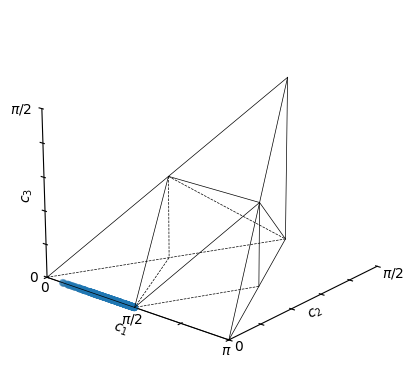

In [4]:
invariant_list = []
for i in trange(200):
    qc = QuantumCircuit(2)
    for i in range(4):
        # qc.append(CXGate(), [0, 1])
        qc.append(UnitaryGate(random_unitary(2)).control(1), [0, 1])
        qc.append(
            UGate(
                np.random.uniform(0, 2 * np.pi),
                np.random.uniform(0, 2 * np.pi),
                np.random.uniform(0, 2 * np.pi),
            ),
            [1],
        )
        if i % 2 == 0:
            qc.append(RZGate(np.random.uniform(0, 2 * np.pi)), [0])
        else:
            qc.append(XGate(), [0])
    #######################################
    target = GateInvariants.from_unitary(Operator(qc))
    invariant_list.append(target)

from gulps.viz.invariant_viz import scatter_plot

scatter_plot(invariant_list)

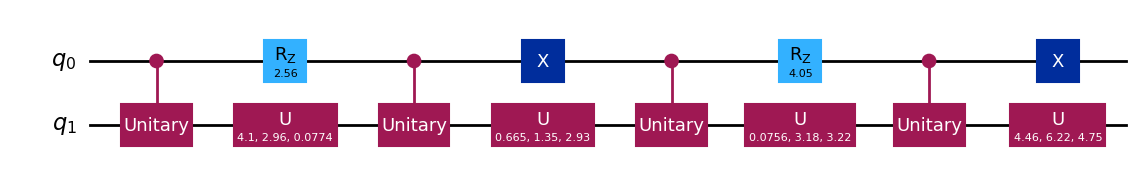

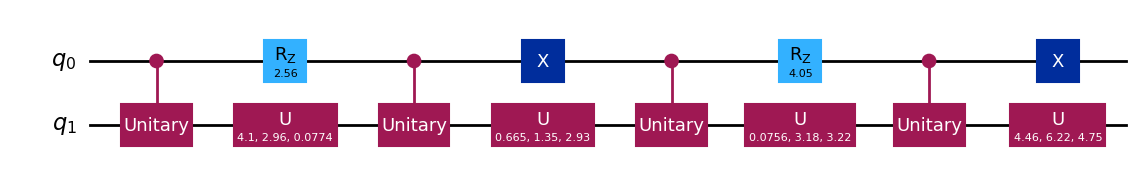

In [5]:
qc.draw("mpl")

In [6]:
import qutip as qt

qt.Qobj(Operator(qc).to_matrix())

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-7.55691617e-01+5.87727622e-01j -3.00141028e-16-5.58338629e-16j
   1.02576759e-01+2.70156308e-01j -4.85397318e-16+8.05014057e-17j]
 [-3.56376437e-16-2.68067317e-16j -4.43373456e-01-2.68427049e-01j
   4.10736464e-17-1.46480360e-16j  7.93297332e-01+3.19446774e-01j]
 [ 7.96877415e-02+2.77770204e-01j  9.93322441e-17+3.36123952e-16j
  -9.57168323e-01-1.79549359e-02j  1.48080943e-16+4.89402715e-16j]
 [ 5.39452804e-16-4.81954798e-16j -7.65976058e-01-3.80325619e-01j
  -4.67511920e-16+2.53657133e-16j -4.95258715e-01-1.52813308e-01j]]

Is U_L unitary? True
Leakage ||(I - VV†) U V|| = 0.0
U_L =
 [[8.44078473e-18+1.j 0.00000000e+00+0.j 0.00000000e+00+0.j
  0.00000000e+00+0.j]
 [0.00000000e+00+0.j 1.00000000e+00+0.j 0.00000000e+00+0.j
  0.00000000e+00+0.j]
 [0.00000000e+00+0.j 0.00000000e+00+0.j 8.44078473e-18+1.j
  0.00000000e+00+0.j]
 [0.00000000e+00+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j
  1.00000000e+00+0.j]]


Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[8.44078473e-18+1.j 0.00000000e+00+0.j 0.00000000e+00+0.j
  0.00000000e+00+0.j]
 [0.00000000e+00+0.j 1.00000000e+00+0.j 0.00000000e+00+0.j
  0.00000000e+00+0.j]
 [0.00000000e+00+0.j 0.00000000e+00+0.j 8.44078473e-18+1.j
  0.00000000e+00+0.j]
 [0.00000000e+00+0.j 0.00000000e+00+0.j 0.00000000e+00+0.j
  1.00000000e+00+0.j]]

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

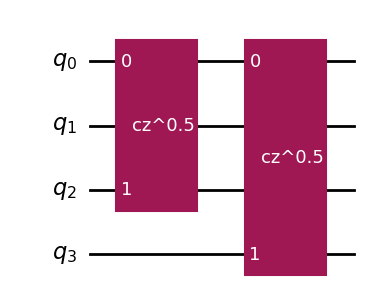

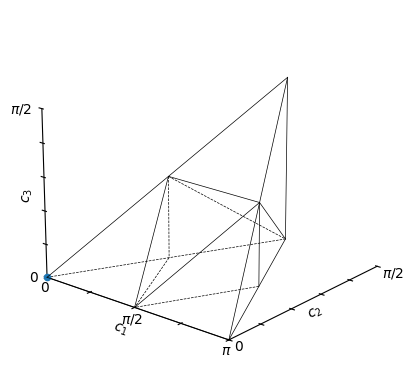

In [22]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Statevector
from qiskit.circuit.library import CZGate, XGate, YGate, HGate
from qiskit.circuit import ControlledGate

# --- 1) Physical 4-qubit unitary ---
qc = QuantumCircuit(4)
u = random_unitary(4)

qc.append(CZGate().power(1 / 2), [0, 2])
qc.append(CZGate().power(1 / 2), [0, 3])
# qc.append(CZGate(), [1, 2])
# qc.append(u.adjoint(), [0, 1])
# qc.append(CZGate(), [1, 2])
# qc.cswap(2, 0, 1)
# qc.cx(1, 0)
# qc.append(UnitaryGate(HGate()).control(1), [2, 1])
# qc.cx(1, 0)
U_phys = Operator(qc).data  # 16x16

# --- 2) Build the 16x4 encoding isometry V ---
# Columns correspond to |00>_L, |01>_L, |10>_L, |11>_L (in that order)
codewords = ["0101", "0110", "1001", "1010"]  # physical |q3 q2 q1 q0> labels in Qiskit

V = np.column_stack([Statevector.from_label(s).data for s in codewords])  # 16x4

# Sanity checks: isometry property
assert np.allclose(V.conj().T @ V, np.eye(4)), "V is not an isometry (V†V != I)."

# --- 3) Project U_phys onto code space ---
U_L = V.conj().T @ U_phys @ V  # 4x4

# If the physical circuit preserves the code space, U_phys V == V U_L and U_L is unitary.
print("Is U_L unitary?", np.allclose(U_L.conj().T @ U_L, np.eye(4), atol=1e-12))

# Optional: leakage check (does U_phys take codewords outside code space?)
leak = np.linalg.norm((np.eye(16) - V @ V.conj().T) @ (U_phys @ V))
print("Leakage ||(I - VV†) U V|| =", leak)

print("U_L =\n", U_L)
display(qt.Qobj(U_L))
qc.draw("mpl")

# plot gate invariant of U_L
from gulps.viz.invariant_viz import scatter_plot

GateInvariants.from_unitary(U_L).plot()